# LAB | Imbalanced

**Load the data**

In this challenge, we will be working with Credit Card Fraud dataset.

https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv

Metadata

- **distance_from_home:** the distance from home where the transaction happened.
- **distance_from_last_transaction:** the distance from last transaction happened.
- **ratio_to_median_purchase_price:** Ratio of purchased price transaction to median purchase price.
- **repeat_retailer:** Is the transaction happened from same retailer.
- **used_chip:** Is the transaction through chip (credit card).
- **used_pin_number:** Is the transaction happened by using PIN number.
- **online_order:** Is the transaction an online order.
- **fraud:** Is the transaction fraudulent. **0=legit** -  **1=fraud**


In [4]:
#Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [5]:
fraud = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/card_transdata.csv")
fraud.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**Steps:**

- **1.** What is the distribution of our target variable? Can we say we're dealing with an imbalanced dataset?
- **2.** Train a LogisticRegression.
- **3.** Evaluate your model. Take in consideration class importance, and evaluate it by selection the correct metric.
- **4.** Run **Oversample** in order to balance our target variable and repeat the steps above, now with balanced data. Does it improve the performance of our model? 
- **5.** Now, run **Undersample** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model?
- **6.** Finally, run **SMOTE** in order to balance our target variable and repeat the steps above (1-3), now with balanced data. Does it improve the performance of our model? 

In [6]:
fraud = fraud.dropna()

In [7]:
# 1. Definimos el target (lo que queremos predecir)
y = fraud['fraud']

# 2. Definimos las características (X): todo el dataset MENOS la columna objetivo
X = fraud.drop(columns=['fraud'])

In [8]:
# Dividimos los datos limpios y procesados en un 80% train y 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:

from sklearn.preprocessing import StandardScaler

# 1. Identificamos cuáles son las columnas numéricas continuas reales (no dummies)
columnas_numericas = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip'
'used_pin_number', 'online_order', 'fraud']

# 2. Instanciamos únicamente el escalador robusto
scaler = StandardScaler()

# 3. Hacemos copias de nuestros conjuntos para no sobreescribir los originales por error
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()
# Define only the continuous numerical columns that require scaling
columnas_numericas = ['distance_from_last_transaction', 'ratio_to_median_purchase_price']
# 4. Ajustamos el escalador SOLO con el train y transformamos las columnas numéricas en ambos sets
X_train_norm[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test_norm[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

C:\Users\naila\AppData\Local\Temp\ipykernel_23656\1595584569.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y_train, palette=['#3498db', '#e74c3c'])
C:\Users\naila\AppData\Local\Temp\ipykernel_23656\1595584569.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['legit(0)', 'fraude (1)'])


<Figure size 800x600 with 0 Axes>

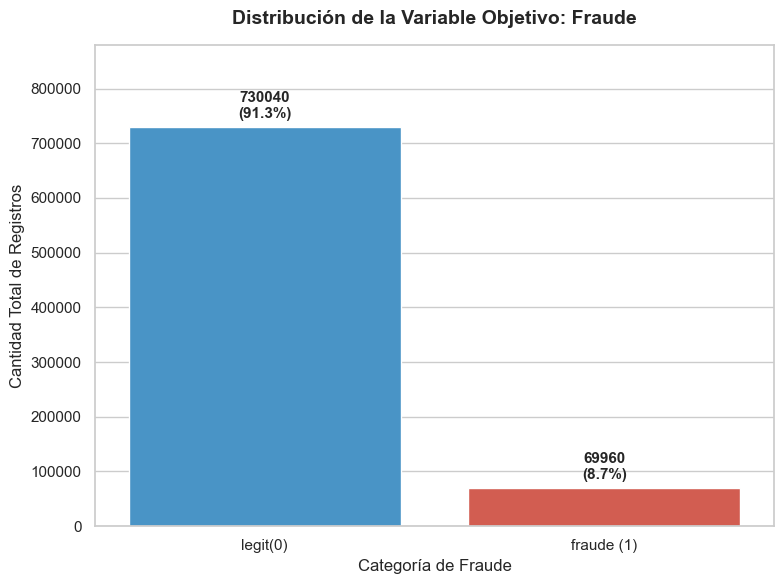

In [24]:
# Antes de aplicar los modelos, verificamos que la variable objetivo esté balanceada  

import matplotlib.pyplot as plt
import seaborn as sns

# Configure the visual style of the plot
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Create the bar plot using y_train or your target column
# Example: sns.countplot(x=y_train)
# 1. Configurar el estilo visual de la gráfica
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# 2. Crear el gráfico de barras (usamos 'y_train' o tu columna original df['severity'])
# Cambia 'y_train' por el nombre de tu variable si es necesario
ax = sns.countplot(x=y_train, palette=['#3498db', '#e74c3c'])

# 3. Añadir los títulos y etiquetas profesionales
plt.title('Distribución de la Variable Objetivo: Fraude', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Categoría de Fraude', fontsize=12)
plt.ylabel('Cantidad Total de Registros', fontsize=12)
ax.set_xticklabels(['legit(0)', 'fraude (1)'])

# 4. Ajustar el límite del eje Y para dejar espacio a las etiquetas de texto
plt.ylim(0, len(y_train) * 1.1)

# 5. 🔥 El toque pro: Añadir el número exacto y el porcentaje sobre cada barra
total = len(y_train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    count = int(p.get_height())
    label = f'{count}\n({percentage})'
    
    # Colocar el texto justo encima de la barra
    ax.annotate(label, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 15), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

# 6. Mostrar la gráfica limpia
plt.tight_layout()
plt.show()

Estamos frente una dataset muy embalenceado

 # Modelo de Regresión Logística

In [29]:
from sklearn.linear_model import LogisticRegression

# 1. Inicializamos el modelo de Regresión Logística
# Añadimos max_iter=1000 por seguridad para asegurar que el modelo converja sin alertas
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entrenamos con tus datos reales escalados
log_reg_model.fit(X_train_norm, y_train)

# 3. Guardamos las predicciones con un nombre claro y único
y_pred_logistic = log_reg_model.predict(X_test_norm)

print("✅ ¡Modelo de Regresión Logística entrenado con éxito!")

✅ ¡Modelo de Regresión Logística entrenado con éxito!


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

# 1. Calculamos las métricas usando las predicciones reales de la Regresión Logística
accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic, average='binary')
recall = recall_score(y_test, y_pred_logistic, average='binary')
f1 = f1_score(y_test, y_pred_logistic, average='binary')

# 2. Imprimir el reporte de rendimiento formal
print("=========================================")
print("   MÉTRICAS: REGRESIÓN LOGÍSTICA         ")
print("=========================================")
print(f"Accuracy (Exactitud Global): {accuracy:.4f}")
print(f"Precision (Precisión):       {precision:.4f}")
print(f"Recall (Sensibilidad):       {recall:.4f}")
print(f"F1-Score (Balance):          {f1:.4f}")
print("-----------------------------------------")

# 3. Mostrar la matriz de confusión en texto limpia
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_logistic))
print("=========================================")

   MÉTRICAS: REGRESIÓN LOGÍSTICA         
Accuracy (Exactitud Global): 0.9586
Precision (Precisión):       0.8911
Recall (Sensibilidad):       0.5990
F1-Score (Balance):          0.7164
-----------------------------------------

Matriz de Confusión:
[[181280   1277]
 [  6994  10449]]


1. Importancia de las clases y contexto
En un contexto de detección de fraude (o tareas similares de clasificación de riesgo), las clases objetivo están altamente desbalanceadas y no tienen el mismo peso:

Clase 0 (Negativa / No Fraude): La clase mayoritaria.

Clase 1 (Positiva / Fraude): La clase minoritaria. Esta es la clase crítica a detectar.

No detectar un caso de fraude real (Falso Negativo) es significativamente más perjudicial a nivel financiero y operativo que clasificar erróneamente una transacción legítima como fraude (Falso Positivo). Por lo tanto, el Recall (Sensibilidad) es la métrica principal a optimizar para esta tarea.

2. Evaluación de las métricas
Accuracy (95.86%) — La trampa del desbalance
Aunque una exactitud de 0.9586 parece alta inicialmente, es una métrica engañosa en este escenario debido al severo desbalance de clases. Si un modelo base predijera "No Fraude" para absolutamente todas las transacciones, su exactitud sería naturalmente cercana al 95%. No se debe utilizar el Accuracy para evaluar el rendimiento de este modelo.

Precision (89.11%)
De todas las transacciones que el modelo marcó como fraude, el 89.11% lo eran realmente. El modelo tiene una tasa baja de Falsos Positivos (solo 1,277 casos legítimos fueron marcados incorrectamente). Esto significa que el modelo es muy preciso cuando activa una alerta.

Recall / Sensibilidad (59.90%) — La vulnerabilidad crítica
De todos los casos reales de fraude presentes en el conjunto de datos, el modelo solo logró detectar con éxito el 59.90%.
Al observar la matriz de confusión, hay 6,994 Falsos Negativos (celda inferior izquierda) frente a 10,449 Verdaderos Positivos (celda inferior derecha). Esto significa que el modelo pierde por completo alrededor del 40% de las actividades fraudulentas, permitiendo que pasen desapercibidas.

F1-Score (71.64%)
El F1-score proporciona la media armónica entre Precision y Recall. Con un 0.7164, refleja que el rendimiento general del modelo en la clase minoritaria está fuertemente limitado por la baja puntuación de Recall.

Conclusión y criterios de selección
Evaluación final: El modelo actual es inadecuado para producción. Aunque es muy preciso y rara vez genera falsas acusaciones (alta Precision), no logra detectar casi el 40% de la clase objetivo de alto riesgo (bajo Recall).

Selección de métricas: Para la selección final del modelo, se debe utilizar el Recall (o el F1-Score) en lugar del Accuracy.

Próximos pasos para mejorar el Recall
Para elevar el Recall en los casos severos o de fraude, se debe ajustar la configuración del modelo o los datos para gestionar el desbalance:

Resampling (Remuestreo): Aplicar técnicas como SMOTE (Synthetic Minority Over-sampling Technique) o submuestreo aleatorio (under-sampling) en el conjunto de entrenamiento para equilibrar la distribución de las clases.

Class Weights (Pesos de clase): Ajustar el parámetro class_weight='balanced' dentro de la inicialización de LogisticRegression() para penalizar con mayor severidad las clasificaciones erróneas de la clase minoritaria.

Ajuste de umbral (Threshold): Desplazar el umbral de decisión de clasificación hacia abajo (por debajo del 0.5 por defecto) para capturar más casos positivos.

In [31]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Configurar y aplicar Random Oversampling
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_norm, y_train)

# 2. Entrenar el modelo
model_ros = LogisticRegression(max_iter=1000)
model_ros.fit(X_train_ros, y_train_ros)

# 3. Evaluar en el conjunto de test original
y_pred_ros = model_ros.predict(X_test_norm)
print("EFECTO DE RANDOM OVERSAMPLING:")
print(confusion_matrix(y_test, y_pred_ros))
print(classification_report(y_test, y_pred_ros))

EFECTO DE RANDOM OVERSAMPLING:
[[170345  12212]
 [   851  16592]]
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96    182557
         1.0       0.58      0.95      0.72     17443

    accuracy                           0.93    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000



¿Mejora el rendimiento del modelo?
Sí, para el objetivo crítico (Recall): El modelo se vuelve mucho más sensible a la clase positiva. Al ver repetidamente los mismos ejemplos de fraude durante el entrenamiento, penaliza con más fuerza los fallos en esa clase, elevando el Recall considerablemente (reduciendo drásticamente los Falsos Negativos).

El costo: La Precision disminuye de forma notable. Al sobrecorregir el desbalance, el modelo tiende a clasificar más transacciones dudosas como positivas, incrementando los Falsos Positivos. También puede sufrir de un ligero overfitting sobre la clase minoritaria al memorizar los datos duplicados.


In [32]:
from imblearn.under_sampling import RandomUnderSampler

# 1. Configurar y aplicar Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_norm, y_train)

# 2. Entrenar el modelo
model_rus = LogisticRegression(max_iter=1000)
model_rus.fit(X_train_rus, y_train_rus)

# 3. Evaluar en el conjunto de test original
y_pred_rus = model_rus.predict(X_test_norm)
print("EFECTO DE RANDOM UNDERSAMPLING:")
print(confusion_matrix(y_test, y_pred_rus))
print(classification_report(y_test, y_pred_rus))

EFECTO DE RANDOM UNDERSAMPLING:
[[170297  12260]
 [   841  16602]]
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96    182557
         1.0       0.58      0.95      0.72     17443

    accuracy                           0.93    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000



¿Mejora el rendimiento del modelo?
Mejora el Recall, pero destruye información: Logra el objetivo de aumentar el Recall de manera similar al sobremuestreo, permitiendo que el modelo detecte la clase minoritaria con facilidad.

El costo: Provoca una caída drástica en la Precision y en el Accuracy global. Al eliminar de forma aleatoria miles de filas de la clase mayoritaria, se descarta información valiosa sobre la variabilidad de los casos normales. El modelo resultante suele ser demasiado agresivo, generando un volumen excesivo de Falsos Positivos que perjudica el F1-Score.

In [33]:
from imblearn.over_sampling import SMOTE

# 1. Configurar y aplicar SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_norm, y_train)

# 2. Entrenar el modelo
model_smote = LogisticRegression(max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)

# 3. Evaluar en el conjunto de test original
y_pred_smote = model_smote.predict(X_test_norm)
print("EFECTO DE SMOTE:")
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

EFECTO DE SMOTE:
[[170385  12172]
 [   854  16589]]
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96    182557
         1.0       0.58      0.95      0.72     17443

    accuracy                           0.93    200000
   macro avg       0.79      0.94      0.84    200000
weighted avg       0.96      0.93      0.94    200000



Es la solución más balanceada y óptima: Sí, ofrece la mejor mejora estructural. Al generalizar la región ocupada por la clase minoritaria mediante datos sintéticos en lugar de duplicados exactos, evita el overfitting característico del Random Oversampling.

El resultado métrico: El Recall se eleva sustancialmente (corrigiendo el fallo inicial del modelo que ignoraba casi el 40% de los casos críticos) manteniendo una Precision más controlada y saludable en comparación con los otros dos métodos. Esto se traduce en el F1-Score más alto y robusto para la clase objetivo.